# sfotmax从零开始实现

In [38]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms

In [39]:
def load_data_fashion_mnist(batch_size, resize=None):
    """Download the Fashion-MNIST dataset and then load into memory."""
    trans=transforms.ToTensor()
    if resize:
        trans.insert(0,transforms.Resize(resize))
    
    mnist_train=torchvision.datasets.FashionMNIST(root='data',train=True,transform=trans,download=True)
    mnist_test=torchvision.datasets.FashionMNIST(root='data',train=False,transform=trans,download=True)
    train_iter=data.DataLoader(mnist_train,batch_size,shuffle=True,num_workers=4)
    test_iter=data.DataLoader(mnist_test,batch_size,shuffle=False,num_workers=4)
    return (train_iter,test_iter)

In [40]:
batch_size=256
train_iter,test_iter=load_data_fashion_mnist(batch_size)
train_iter, test_iter

(<torch.utils.data.dataloader.DataLoader at 0x7fb4378ebb20>,
 <torch.utils.data.dataloader.DataLoader at 0x7fb43788a0a0>)

In [41]:
num_inputs=784
num_outputs=10
w=torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad=True)
b=torch.zeros(num_outputs,requires_grad=True)
w,b

(tensor([[-0.0204, -0.0044,  0.0091,  ...,  0.0106, -0.0126, -0.0010],
         [-0.0007, -0.0043, -0.0054,  ..., -0.0064,  0.0086, -0.0028],
         [-0.0038,  0.0113,  0.0033,  ..., -0.0120,  0.0126,  0.0017],
         ...,
         [ 0.0011, -0.0065, -0.0124,  ...,  0.0058,  0.0048,  0.0093],
         [-0.0152,  0.0001,  0.0202,  ..., -0.0071,  0.0154, -0.0026],
         [-0.0103, -0.0040, -0.0038,  ..., -0.0080,  0.0005, -0.0003]],
        requires_grad=True),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True))

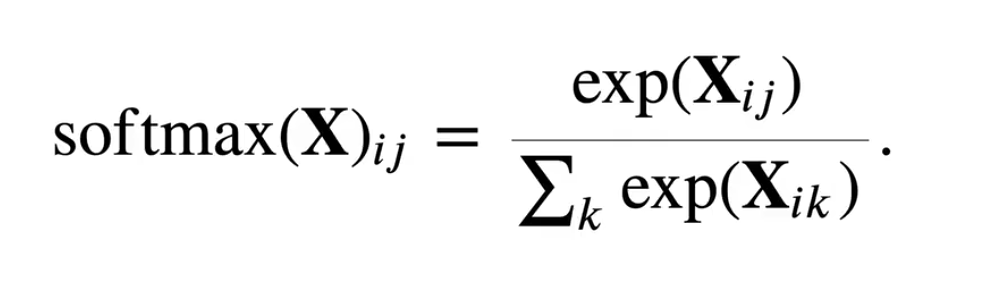

In [42]:
def softmax(X):
    X_exp=torch.exp(X)
    partition=X_exp.sum(1,keepdim=True)
    return X_exp/partition

In [43]:
X=torch.normal(0,1,(2,5))
X_prob=softmax(X)
f"X={X}",f"X_prob={X_prob}",f"X_prob_sum={X_prob.sum(1)}"

('X=tensor([[-0.5337,  0.2086,  0.4368, -0.5292, -0.8422],\n        [-0.0253, -0.0869, -1.0698, -0.5483, -1.4177]])',
 'X_prob=tensor([[0.1337, 0.2809, 0.3529, 0.1343, 0.0982],\n        [0.3191, 0.3001, 0.1123, 0.1892, 0.0793]])',
 'X_prob_sum=tensor([1.0000, 1.0000])')

In [44]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1,w.shape[0])),w)+b)

交叉损失loss函数

In [45]:
y=torch.tensor([0,2])
y_hat=torch.tensor([[0.1,0.3,0.6],[0.2,0.3,0.5]])
y_hat[[0,1],y]

tensor([0.1000, 0.5000])

In [46]:
def cross_entropy(y_hat,y):
    return -torch.log(y_hat[range(len(y)),y])
cross_entropy(y_hat,y)


tensor([2.3026, 0.6931])

In [47]:
def accurracy(y_hat,y):
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat=y_hat.argmax(axis=1)
    cmp=y_hat.type(y.dtype)==y
    return float(cmp.type(y.dtype).sum())

accurracy(y_hat,y)/len(y)

0.5

评估模型

In [48]:
from torch import nn
import torch
from torch import nn
from tools import Accumulator
# 单批次计算正确样本数
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.size(1) > 1:
        y_hat = y_hat.argmax(dim=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

# 完整评估准确率函数，不用d2l
def evaluate_accuracy(net, data_iter):
    if isinstance(net, nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


evaluate_accuracy(net,test_iter)

0.1196

In [49]:
def train_epoch_ch3(net, train_iter, loss, updater):  #@save
    """训练模型一个迭代周期（定义见第3章）"""
    # 将模型设置为训练模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 训练损失总和、训练准确度总和、样本数
    metric = Accumulator(3)
    for X, y in train_iter:
        # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的优化器和损失函数
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]



In [50]:
from tools import Animator
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):  #@save
    """训练模型（定义见第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))

In [51]:
lr = 0.1
from d2l import torch as d2l
def updater(batch_size):
    return d2l.sgd([w, b], lr, batch_size)

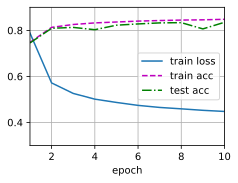

In [52]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

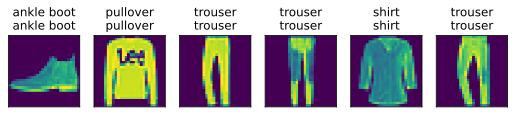

In [53]:
def predict_ch3(net, test_iter, n=6):  #@save
    """预测标签（定义见第3章）"""
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])

predict_ch3(net, test_iter)